# Data Validation

## Workspace Initialization

In [62]:
import pandas as pd

In [63]:
df = pd.read_csv('../data/raw/ecommerce_customer_churn_dataset.csv')
df.shape

(50000, 25)

In [64]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

---

## Identify Suspecious Columns
This section identifies the suspecious columns in that hold invalid values.

### Categorical Columns

In [65]:
df.describe(include=object)

,Gender,Country,City,Signup_Quarter
count,50000,50000,50000,50000
unique,3,8,40,4
top,Female,USA,Houston,Q3
freq,25116,17384,3549,12558


In [66]:
cat_cols = df.select_dtypes(object).columns
df[cat_cols].nunique()

Gender             3
Country            8
City              40
Signup_Quarter     4
dtype: int64

In [67]:
[df[col].unique() for col in cat_cols]

[array(['Male', 'Female', 'Other'], dtype=object),
 array(['France', 'UK', 'Canada', 'USA', 'India', 'Japan', 'Germany',
        'Australia'], dtype=object),
 array(['Marseille', 'Manchester', 'Vancouver', 'New York', 'Delhi',
        'Tokyo', 'Berlin', 'Houston', 'Calgary', 'Glasgow', 'Munich',
        'Phoenix', 'Paris', 'Ottawa', 'Los Angeles', 'Bangalore',
        'Adelaide', 'Yokohama', 'Sydney', 'Nagoya', 'Frankfurt', 'Cologne',
        'Hamburg', 'Nice', 'Chicago', 'Toulouse', 'Brisbane', 'Leeds',
        'Mumbai', 'Montreal', 'Melbourne', 'Osaka', 'Lyon', 'Hyderabad',
        'Chennai', 'Birmingham', 'London', 'Toronto', 'Perth', 'Kyoto'],
       dtype=object),
 array(['Q1', 'Q4', 'Q2', 'Q3'], dtype=object)]

Remarks:
* `Gender`: Other attribute can be indication of 'prefer not to say' or customer never provided gender info. 
* Other 3 columns have valid city and country names, valid quarter terminology.
* `City` is like a subcategory of `Country` column, and we skip validation of city subclasses belongs to right country class or not. 

### Numeric Columns

In [68]:
df.describe().loc['min']

Age                               5.00
Membership_Years                  0.10
Login_Frequency                   0.00
Session_Duration_Avg              1.00
Pages_Per_Session                 1.00
Cart_Abandonment_Rate             0.00
Wishlist_Items                    0.00
Total_Purchases                 -13.00
Average_Order_Value              26.38
Days_Since_Last_Purchase          0.00
Discount_Usage_Rate               0.24
Returns_Rate                      0.00
Email_Open_Rate                   0.00
Customer_Service_Calls            0.00
Product_Reviews_Written           0.00
Social_Media_Engagement_Score     0.00
Mobile_App_Usage                  0.00
Payment_Method_Diversity          1.00
Lifetime_Value                    0.00
Credit_Balance                    0.00
Churned                           0.00
Name: min, dtype: float64

In [69]:
df.describe().loc['max']

Age                               200.000000
Membership_Years                   10.000000
Login_Frequency                    46.000000
Session_Duration_Avg               75.600000
Pages_Per_Session                  24.100000
Cart_Abandonment_Rate             143.743350
Wishlist_Items                     28.000000
Total_Purchases                   128.700000
Average_Order_Value              9666.379178
Days_Since_Last_Purchase          287.000000
Discount_Usage_Rate               116.640000
Returns_Rate                       99.615734
Email_Open_Rate                    91.700000
Customer_Service_Calls             21.000000
Product_Reviews_Written            21.000000
Social_Media_Engagement_Score     100.000000
Mobile_App_Usage                   61.900000
Payment_Method_Diversity            5.000000
Lifetime_Value                   8987.240000
Credit_Balance                   7197.000000
Churned                             1.000000
Name: max, dtype: float64

Suspecious columns `min` stats:
* **KEEP** `Login_Frequency` (Average number of logins per month) is 0: User must have login atleast 1 time in the life, or the first login was through signup which are not considered in this variable. **ASSUMED** the later one.
* **FURTHER ANALYSE** `Total_Purchases` (Total number of purchases made) is -ve:  customers have more return orders where business incurr loss over revenue, or data collection error.
* **KEEP** `Mobile_App_Usage` (Percentage of activity via mobile app) is 0: Customer may have different mode of access to service, example website, telecalls, sms/whatsapp. 
* **FURTHER ANALYSE** `Lifetime_Value` (Total customer lifetime value in currency units): No purchase so far, or computation error.
* **FURTHER ANALYSE** `Discount_Usage_Rate` (Percentage of purchases using discounts): Customer can not have more than 100% order purchase where discount used. 

Suspecious Columns `max` stats:
* **FURTHER ANALYSE** `Age` (Customer's age in years) is > 100: data collection error

> Need to asses impact size for the columns marked for further analysis.

---

## Assess Suspecious Records
This section assess the impact size of anomaly in identified suspecious columns

### Age 

In [70]:
df.query('Age > 100').shape

(20, 25)

In [71]:
df.query('Age < 100')['Age'].max()

np.float64(75.0)

### Total_Purchases

In [11]:
df.query('Total_Purchases < 0').shape

(40, 25)

In [12]:
df.query('Total_Purchases > 0')['Total_Purchases'].min()

np.float64(1.0)

### Lifetime_Value

In [13]:
df.query('Lifetime_Value == 0').shape

(9, 25)

In [14]:
df.query('Lifetime_Value > 0')['Lifetime_Value'].min()

np.float64(45.48)

### Discount_Usage_Rate

In [15]:
df.query('Discount_Usage_Rate > 100').shape

(207, 25)

**Impact Size**: 69 (20+40+9) records from first 3 suspicious columns {Age, Total_Purchases, Lifetime_Value}

The impact size is on low (69 of 50_000), thereby such records can be easily dropped - however not all of these records are bad. Some holds meaningful signal and might be valid customer record.

In case of Lifetime_Value, customer who never purchased can have 0 ltf.

The `Discount_Usage_Rate` columns have 207 supsicious records, that's 0.4% of dataset. These can be either dropped or flagged. 

### Further Analysis of LTF

In [17]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [18]:
df.query('Lifetime_Value <= 0')[['Total_Purchases', 
                                 'Average_Order_Value', 
                                 'Days_Since_Last_Purchase', 
                                 'Returns_Rate']]

,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Returns_Rate
2198,0.0,68.26,28.0,4.4
15196,0.0,78.67,2.0,4.0
15794,0.0,194.75,13.0,15.2
23747,0.0,139.90,21.0,6.2
31584,0.0,58.74,1.0,11.3
32581,0.0,62.45,23.0,2.2
33939,0.0,46.65,0.0,12.8
38702,0.0,101.66,10.0,NaN
40098,0.0,124.49,20.0,1.2


In [19]:
df.query('Total_Purchases == 0').shape

(9, 25)

Records with 0 LTF are invalid records, appearing along with 0 Total_Purchases.

**Conclusion** All the 69 anomaly records are invalid and can be dropped.

### Further analysis of Discount_Usage_Rate

In [38]:
df.query('Discount_Usage_Rate > 100')\
    [['Average_Order_Value', 'Lifetime_Value', 'Total_Purchases', 'Membership_Years']].describe()

,Average_Order_Value,Lifetime_Value,Total_Purchases,Membership_Years
count,197.000000,197.000000,197.000000,197.000000
mean,121.600660,1516.020711,16.127919,3.069543
std,41.968285,878.340016,6.449069,1.939568
min,39.700000,176.320000,2.600000,0.200000
25%,92.360000,905.170000,11.700000,1.700000
50%,120.010000,1380.920000,15.600000,2.700000
75%,148.730000,1942.070000,20.800000,4.100000
max,241.200000,5969.430000,35.100000,10.000000


In [35]:
df[['Average_Order_Value', 'Lifetime_Value', 'Total_Purchases', 'Membership_Years']].describe()

,Average_Order_Value,Lifetime_Value,Total_Purchases,Membership_Years
count,47440.000000,47440.000000,47440.000000,47440.000000
mean,123.303317,1440.994712,13.131564,2.981112
std,179.940439,906.448135,6.994213,2.059881
min,26.380000,45.480000,1.000000,0.100000
25%,87.047500,789.827500,8.000000,1.400000
50%,112.960000,1243.830000,12.000000,2.500000
75%,144.470000,1875.470000,17.000000,4.000000
max,9666.379178,8987.240000,128.700000,10.000000


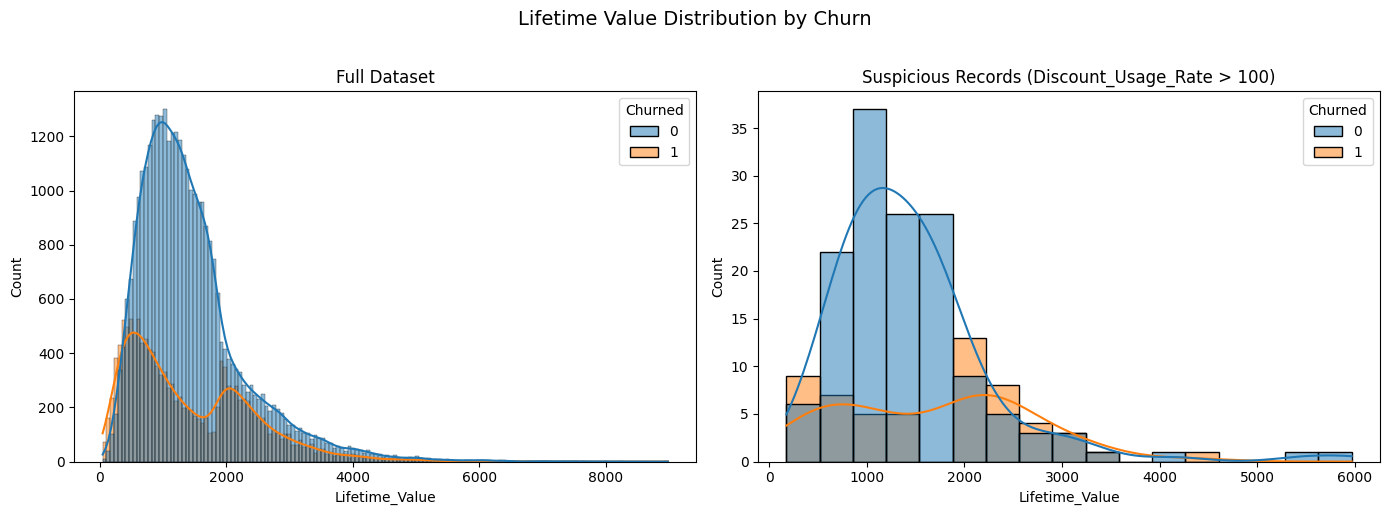

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.histplot(df, kde=True, x='Lifetime_Value', hue='Churned', ax=axes[0])
axes[0].set_title('Full Dataset')

sns.histplot(df.query('Discount_Usage_Rate > 100'), kde=True, x='Lifetime_Value', hue='Churned', ax=axes[1])
axes[1].set_title('Suspicious Records (Discount_Usage_Rate > 100)')

plt.suptitle('Lifetime Value Distribution by Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [59]:
df['Churned'].value_counts(normalize=True) * 100

Churned
0    70.908516
1    29.091484
Name: proportion, dtype: float64

The invalid `Discount_Usage_Rate` records (n=197) were **flagged** rather than dropped because:

- In the suspicious group, high-value customers show a notably higher churn concentration compared to the full dataset — suggesting these records may carry a real behavioral signal worth preserving.
- With an overall churn rate of ~30%, discarding any churned customer records risks losing high profile customers which business can't afford at this stage.

For the remaining invalid cases (n=20, 40, and 9 across other features), records were **dropped** without further analysis. At < 0.15% of total data combined, their impact on model performance and business will likely be close to negligible, and the cost of retention outweighs any potential signal.

---
## Cross-Column Relation

This section identifies invalid records where values across columns contradict each other logically.

In [21]:
df.query('Membership_Years > Age').shape

(5, 25)

In [22]:
# very high pages per session but 
high_pages = df["Pages_Per_Session"].quantile(0.9)
low_duration = df["Session_Duration_Avg"].quantile(0.1)

((df["Pages_Per_Session"] > high_pages) & 
 (df["Session_Duration_Avg"] < low_duration))\
     .sum()

np.int64(0)

In [23]:
df.query('Lifetime_Value < Total_Purchases * Average_Order_Value').shape

(29928, 25)

Remarks:
* `Membership_Years > Age`: This column will be dropped.
* `Lifetime_Value < Total_Purchases * Average_Order_Value`: Lifetime_Value is probably a forecast and not direct historical value of customer. This aligns with descriptions provided by dataset publisher.

---

## Conclusion
* Identified invalid values in `Age`, `Total_Purchases`, `Lifetime_Value`, `Discount_Usage_Rate`, and a cross-column anomaly in `Membership_Years > Age`.
* **Drop** 69 records across `Age` (n=20), `Total_Purchases` (n=40), and `Lifetime_Value` (n=9) — all confirmed invalid with no meaningful signal, representing < 0.15% of the dataset.
* **Drop** records where `Membership_Years > Age` — logically impossible and likely a data entry error.
* **Flag** `Discount_Usage_Rate > 100` (n=197) with a binary column rather than dropping, as the distribution analysis revealed a disproportionately higher churn concentration in this group compared to the full dataset — suggesting a potential behavioral signal worth preserving for modeling.